# 02 — Analisi del trade-off Rate–Distortion nei VAE audio
In questo notebook viene studiato il trade-off tra capacità informativa dello spazio latente e qualità della ricostruzione in un Variational Autoencoder applicato a segnali audio.
Per diversi valori del parametro \(\beta\), il modello viene inizializzato dallo stesso autoencoder deterministico pre-addestrato e successivamente ottimizzato introducendo la regolarizzazione KL.

Per ciascun modello vengono misurati:

$$ R=\mathbb{E}_x\left[KL(q_\phi(z|x)\|p(z))\right] $$

e

$$ D=\text{weighted log-STFT MSE}. $$

L’obiettivo è osservare come la riduzione del Rate influenzi progressivamente la Distortion e individuare la regione più significativa della curva Rate–Distortion.


## 1. Librerie e configurazione

In [10]:
from pathlib import Path
import wave as waveio

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torchaudio

from torch.utils.data import Dataset, DataLoader
from IPython.display import Audio, display

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEED = 42

SAMPLE_RATE = 8000
N_SAMPLES = 8000

N_FFT = 256
HOP_LENGTH = 64
SPEC_H = 128
SPEC_W = 128

LATENT_DIM = 128
BATCH_SIZE = 64

EPOCHS = 5
LEARNING_RATE = 5e-5
PRESERVE_WEIGHT = 0.5

NOISE_STD = 0.05
PADDING_WEIGHT = 0.10

BETAS = [
    0.0,
    1e-6,
    3e-6,
    1e-5,
    3e-5,
    1e-4,
    3e-4,
    1e-3,
    3e-3,
    1e-2
]

torch.manual_seed(SEED)
np.random.seed(SEED)

print("device:", device)
print("betas:", BETAS)


CHECKPOINT_DIR = Path("checkpoints")
RESULTS_DIR = Path("results")
CHECKPOINT_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)


device: cpu
betas: [0.0, 1e-06, 3e-06, 1e-05, 3e-05, 0.0001, 0.0003, 0.001, 0.003, 0.01]


## 2. Preparazione del dataset FSDD

In [11]:
recordings_dir = Path("audio_data/free-spoken-digit-dataset-1.0.10/recordings")
wav_files = sorted(recordings_dir.glob("*.wav"))

if len(wav_files) == 0:
    raise FileNotFoundError("Dataset FSDD non trovato.")

def parse_name(path):
    digit, speaker, index = path.stem.split("_")
    return int(digit), speaker, int(index)

def load_fixed_audio(path):
    with waveio.open(str(path), "rb") as f:
        sr = f.getframerate()
        channels = f.getnchannels()
        frames = f.readframes(f.getnframes())

    audio = np.frombuffer(
        frames,
        dtype=np.int16
    ).astype(np.float32) / 32768.0

    if channels > 1:
        audio = audio.reshape(-1, channels).mean(axis=1)

    waveform = torch.tensor(audio).unsqueeze(0)

    if sr != SAMPLE_RATE:
        waveform = torchaudio.functional.resample(
            waveform,
            sr,
            SAMPLE_RATE
        )

    valid_length = min(
        waveform.shape[1],
        N_SAMPLES
    )

    if waveform.shape[1] < N_SAMPLES:
        waveform = F.pad(
            waveform,
            (0, N_SAMPLES - waveform.shape[1])
        )
    else:
        waveform = waveform[:, :N_SAMPLES]

    mask = torch.zeros_like(waveform)
    mask[:, :valid_length] = 1.0

    return waveform, mask, valid_length

train_files = []
test_files = []

for path in wav_files:
    _, _, idx = parse_name(path)

    if idx <= 4:
        test_files.append(path)
    else:
        train_files.append(path)

print("Train:", len(train_files))
print("Test :", len(test_files))


Train: 2700
Test : 300


## 3. Rappresentazione STFT e normalizzazione

In [12]:
window = torch.hann_window(N_FFT)

def stft_complex(x):
    return torch.stft(
        x.squeeze(0),
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=N_FFT,
        window=window,
        return_complex=True
    )

def crop_logmag(logmag):
    logmag = logmag[:SPEC_H, :]

    if logmag.shape[1] < SPEC_W:
        logmag = F.pad(
            logmag,
            (0, SPEC_W - logmag.shape[1])
        )
    else:
        logmag = logmag[:, :SPEC_W]

    return logmag

def frame_weights(valid_length):
    valid_frames = (
        int(np.ceil(valid_length / HOP_LENGTH))
        + 1
    )

    valid_frames = min(
        valid_frames,
        SPEC_W
    )

    w = torch.full(
        (1, SPEC_H, SPEC_W),
        PADDING_WEIGHT,
        dtype=torch.float32
    )

    w[:, :, :valid_frames] = 1.0

    return w

sum_x = 0.0
sum_x2 = 0.0
count_values = 0

for path in train_files:
    clean, _, _ = load_fixed_audio(path)

    X = stft_complex(clean)

    logmag = crop_logmag(
        torch.log1p(X.abs())
    )

    sum_x += logmag.sum().item()
    sum_x2 += (logmag ** 2).sum().item()
    count_values += logmag.numel()

SPEC_MEAN = sum_x / count_values

variance = (
    sum_x2 / count_values
    - SPEC_MEAN ** 2
)

SPEC_STD = max(
    variance,
    1e-8
) ** 0.5

print("SPEC_MEAN:", SPEC_MEAN)
print("SPEC_STD :", SPEC_STD)


SPEC_MEAN: 0.04547776059049216
SPEC_STD : 0.16703430628401916


## 4. Costruzione delle rappresentazioni spettrali

In [13]:
class SpectrogramDataset(Dataset):
    def __init__(self, files):
        self.files = files

    def __len__(self):
        return len(self.files)

    def __getitem__(self, i):
        clean, mask, valid_length = load_fixed_audio(
            self.files[i]
        )

        # stesso rumore per lo stesso file
        g = torch.Generator().manual_seed(
            10000 + i
        )

        noise = torch.randn(
            clean.shape,
            generator=g
        )

        noisy = torch.clamp(
            clean + NOISE_STD * noise * mask,
            -1.0,
            1.0
        )

        clean_stft = stft_complex(clean)
        noisy_stft = stft_complex(noisy)

        clean_logmag = crop_logmag(
            torch.log1p(clean_stft.abs())
        )

        noisy_logmag = crop_logmag(
            torch.log1p(noisy_stft.abs())
        )

        clean_img = (
            (clean_logmag - SPEC_MEAN)
            / SPEC_STD
        ).unsqueeze(0)

        noisy_img = (
            (noisy_logmag - SPEC_MEAN)
            / SPEC_STD
        ).unsqueeze(0)

        weights = frame_weights(
            valid_length
        )

        digit, _, _ = parse_name(
            self.files[i]
        )

        return (
            noisy_img,
            clean_img,
            weights,
            digit
        )

train_dataset = SpectrogramDataset(
    train_files
)

test_dataset = SpectrogramDataset(
    test_files
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Dataset pronto")


Dataset pronto


## 5. Architettura dell’autoencoder e del VAE

In [14]:
class STFTAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.ReLU()
        )

        self.fc_encode = nn.Linear(
            128 * 16 * 16,
            LATENT_DIM
        )

        self.fc_decode = nn.Linear(
            LATENT_DIM,
            128 * 16 * 16
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(
                128, 64, 4, 2, 1
            ),
            nn.ReLU(),
            nn.ConvTranspose2d(
                64, 32, 4, 2, 1
            ),
            nn.ReLU(),
            nn.ConvTranspose2d(
                32, 1, 4, 2, 1
            )
        )

    def encode(self, x):
        h = self.encoder(x).flatten(1)
        return self.fc_encode(h)

    def decode(self, z):
        h = self.fc_decode(z).view(
            -1, 128, 16, 16
        )
        return self.decoder(h)

    def forward(self, x):
        return self.decode(
            self.encode(x)
        )


class STFTVAE(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(
            128 * 16 * 16,
            LATENT_DIM
        )

        self.fc_logvar = nn.Linear(
            128 * 16 * 16,
            LATENT_DIM
        )

        self.fc_decode = nn.Linear(
            LATENT_DIM,
            128 * 16 * 16
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(
                128, 64, 4, 2, 1
            ),
            nn.ReLU(),
            nn.ConvTranspose2d(
                64, 32, 4, 2, 1
            ),
            nn.ReLU(),
            nn.ConvTranspose2d(
                32, 1, 4, 2, 1
            )
        )

    def encode(self, x):
        h = self.encoder(x).flatten(1)

        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        return mu, logvar

    def reparameterize(
        self,
        mu,
        logvar,
        tau=1.0
    ):
        sigma = torch.exp(
            0.5 * logvar
        )

        eps = torch.randn_like(
            sigma
        )

        return (
            mu
            + tau * sigma * eps
        )

    def decode(self, z):
        h = self.fc_decode(z).view(
            -1, 128, 16, 16
        )

        return self.decoder(h)


checkpoint = CHECKPOINT_DIR / "stft_autoencoder.pt"

if not checkpoint.exists():
    raise FileNotFoundError(
        "Non trovo checkpoints/stft_autoencoder.pt"
    )

ae_state = torch.load(
    checkpoint,
    map_location=device
)

teacher = STFTAutoencoder().to(
    device
)

teacher.load_state_dict(
    ae_state
)

teacher.eval()

for p in teacher.parameters():
    p.requires_grad = False

print("Autoencoder teacher caricato")


Autoencoder teacher caricato


## 6. Funzione obiettivo e inizializzazione dei modelli

In [15]:
def weighted_mse(
    recon,
    target,
    weights
):
    error = (
        recon - target
    ) ** 2

    numerator = (
        error * weights
    ).sum(dim=(1, 2, 3))

    denominator = (
        weights.sum(
            dim=(1, 2, 3)
        )
        .clamp_min(1.0)
    )

    return (
        numerator
        / denominator
    )

def kl_per_example(
    mu,
    logvar
):
    return -0.5 * torch.sum(
        1
        + logvar
        - mu.pow(2)
        - logvar.exp(),
        dim=1
    )

def fresh_vae():
    torch.manual_seed(SEED)

    model = STFTVAE().to(
        device
    )

    vae_state = model.state_dict()

    for key, value in ae_state.items():
        if key.startswith("encoder."):
            vae_state[key] = value

    vae_state["fc_mu.weight"] = (
        ae_state["fc_encode.weight"]
    )

    vae_state["fc_mu.bias"] = (
        ae_state["fc_encode.bias"]
    )

    vae_state["fc_decode.weight"] = (
        ae_state["fc_decode.weight"]
    )

    vae_state["fc_decode.bias"] = (
        ae_state["fc_decode.bias"]
    )

    for key, value in ae_state.items():
        if key.startswith("decoder."):
            vae_state[key] = value

    model.load_state_dict(
        vae_state
    )

    with torch.no_grad():
        model.fc_logvar.weight.zero_()
        model.fc_logvar.bias.fill_(-6.0)

    return model


## 7. Addestramento per ciascun valore di β

Per garantire un confronto controllato tra i diversi valori di β, ogni modello viene inizializzato dallo stesso checkpoint dell’autoencoder deterministico e addestrato mantenendo invariati il seed e l’ordine dei dati.

Durante il fine-tuning, sia l’intensità del campionamento latente τ sia il peso effettivo della regolarizzazione KL (β_eff) vengono aumentati progressivamente.

Al termine dell’addestramento, Rate (R) e Distortion (D) vengono valutati utilizzando z = μ, così da ottenere una ricostruzione deterministica e direttamente confrontabile tra i diversi modelli.

In [ ]:
def train_one_beta(beta_target):
    torch.manual_seed(SEED)
    np.random.seed(SEED)

    model = fresh_vae()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )

    loader_generator = (
        torch.Generator()
        .manual_seed(SEED)
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=loader_generator
    )

    for epoch in range(
        1,
        EPOCHS + 1
    ):
        model.train()

        progress = (
            (epoch - 1)
            / (EPOCHS - 1)
        )

        tau = progress

        beta_eff = (
            beta_target
            * progress
        )

        for (
            noisy_img,
            clean_img,
            weights,
            _
        ) in train_loader:

            noisy_img = noisy_img.to(
                device
            )

            clean_img = clean_img.to(
                device
            )

            weights = weights.to(
                device
            )

            optimizer.zero_grad()

            with torch.no_grad():
                teacher_recon = teacher(
                    noisy_img
                )

            mu, logvar = model.encode(
                noisy_img
            )

            z = model.reparameterize(
                mu,
                logvar,
                tau=tau
            )

            recon = model.decode(z)
            recon_mu = model.decode(mu)

            D = weighted_mse(
                recon,
                clean_img,
                weights
            )

            P = weighted_mse(
                recon_mu,
                teacher_recon,
                weights
            )

            R = kl_per_example(
                mu,
                logvar
            )

            loss = (
                D.mean()
                + PRESERVE_WEIGHT
                * P.mean()
                + beta_eff
                * R.mean()
            )

            loss.backward()
            optimizer.step()

    model.eval()

    total_D = 0.0
    total_R = 0.0
    count = 0

    with torch.no_grad():
        for (
            noisy_img,
            clean_img,
            weights,
            _
        ) in test_loader:

            noisy_img = noisy_img.to(
                device
            )

            clean_img = clean_img.to(
                device
            )

            weights = weights.to(
                device
            )

            mu, logvar = model.encode(
                noisy_img
            )

            recon_mu = model.decode(mu)

            D = weighted_mse(
                recon_mu,
                clean_img,
                weights
            )

            R = kl_per_example(
                mu,
                logvar
            )

            total_D += D.sum().item()
            total_R += R.sum().item()
            count += clean_img.size(0)

    test_D = total_D / count
    test_R = total_R / count

    beta_name = (
        f"{beta_target:.0e}"
        .replace("-", "m")
    )

    torch.save(
        model.state_dict(),
        CHECKPOINT_DIR / f"vae_beta_{beta_name}.pt"
    )

    return (
        model,
        test_D,
        test_R
    )


## 8. Esplorazione dei valori di β

In [17]:
results = []

for beta in BETAS:
    print(
        f"Training beta = {beta:.0e}"
    )

    model, D, R = train_one_beta(
        beta
    )

    results.append(
        {
            "beta": beta,
            "Rate": R,
            "Distortion": D
        }
    )

    print(
        f"  Test D = {D:.5f}"
    )

    print(
        f"  Test R = {R:.2f}"
    )

    print()

results_df = pd.DataFrame(
    results
)

results_df


Training beta = 0e+00
  Test D = 0.24840
  Test R = 769.48

Training beta = 1e-06
  Test D = 0.24839
  Test R = 718.10

Training beta = 3e-06
  Test D = 0.24837
  Test R = 661.14

Training beta = 1e-05
  Test D = 0.24836
  Test R = 576.09

Training beta = 3e-05
  Test D = 0.24848
  Test R = 472.48

Training beta = 1e-04
  Test D = 0.24943
  Test R = 338.12

Training beta = 3e-04
  Test D = 0.25214
  Test R = 222.94

Training beta = 1e-03
  Test D = 0.25914
  Test R = 122.49

Training beta = 3e-03
  Test D = 0.27599
  Test R = 67.33

Training beta = 1e-02
  Test D = 0.32201
  Test R = 33.74



,beta,Rate,Distortion
0,0.000000,769.484440,0.248399
1,0.000001,718.096224,0.248393
2,0.000003,661.143190,0.248369
3,0.000010,576.091107,0.248363
4,0.000030,472.479225,0.248482
5,0.000100,338.115977,0.249429
6,0.000300,222.941859,0.252140
7,0.001000,122.492573,0.259144
8,0.003000,67.326286,0.275989
9,0.010000,33.735151,0.322007


## 9. Curva Rate–Distortion

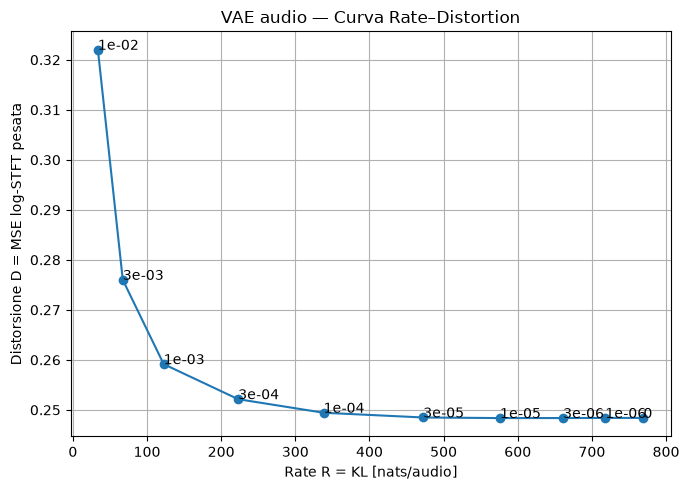

In [23]:
plt.figure(figsize=(7, 5))

plt.plot(
    results_df["Rate"],
    results_df["Distortion"],
    marker="o"
)

for _, row in results_df.iterrows():
    label = (
        "0"
        if row["beta"] == 0
        else f'{row["beta"]:.0e}'
    )

    plt.annotate(
        label,
        (
            row["Rate"],
            row["Distortion"]
        )
    )

plt.xlabel(
    "Rate R = KL [nats/audio]"
)

plt.ylabel(
    "Distorsione D = MSE log-STFT pesata"
)

plt.title(
    "VAE audio — Curva Rate–Distortion"
)
plt.grid(True)
plt.tight_layout()
plt.show()


## 10. Effetto di β su Rate e Distortion

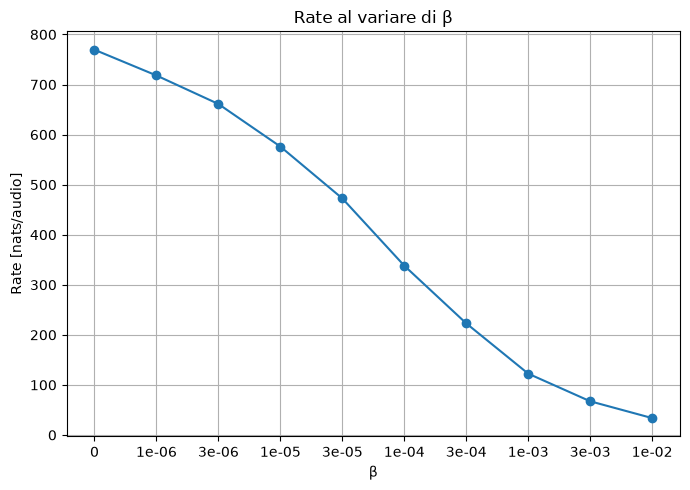

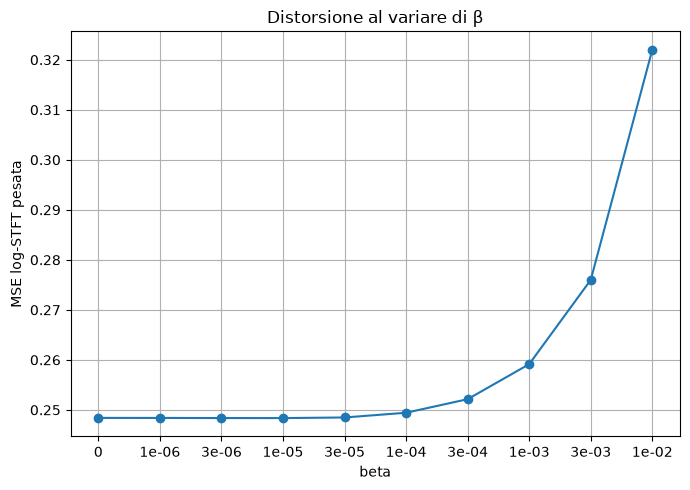

In [24]:
beta_labels = [
    "0"
    if b == 0
    else f"{b:.0e}"
    for b in results_df["beta"]
]

plt.figure(figsize=(7, 5))

plt.plot(
    beta_labels,
    results_df["Rate"],
    marker="o"
)

plt.xlabel("β")
plt.ylabel("Rate [nats/audio]")
plt.title("Rate al variare di β")
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 5))

plt.plot(
    beta_labels,
    results_df["Distortion"],
    marker="o"
)

plt.xlabel("beta")
plt.ylabel(
    "MSE log-STFT pesata"
)

plt.title("Distorsione al variare di β")
plt.grid(True)
plt.tight_layout()
plt.show()


## 11.Salvataggio dei risultati e dei modelli

In [25]:
results_df.to_csv(
    RESULTS_DIR / "rate_distortion_deterministic.csv",
    index=False
)

print(
    "Salvato: step9_rate_distortion_results.csv"
)


Salvato: step9_rate_distortion_results.csv


# Interpretazione dei risultati
I risultati mostrano una relazione chiara tra la regolarizzazione dello spazio latente e la qualità della ricostruzione.

All’aumentare di β, il Rate diminuisce progressivamente. Questo indica che il posterior viene spinto sempre di più verso la distribuzione prior e che lo spazio latente contiene meno informazione specifica sul segnale in ingresso.

Per valori piccoli o moderati di β, il Rate si riduce molto mentre la Distortion aumenta solo leggermente. Per valori più elevati di β, invece, la perdita di informazione latente diventa più marcata e la qualità della ricostruzione peggiora in modo evidente.

La curva Rate–Distortion evidenzia quindi una zona di transizione, o “ginocchio” della curva, in cui è possibile ottenere una forte riduzione del Rate senza compromettere eccessivamente la ricostruzione.

Questa regione sarà particolarmente importante nelle analisi successive, dove verrà studiato anche l’effetto della componente stocastica del VAE.